In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

print("✓ Libraries imported successfully!")


✓ Libraries imported successfully!


In [2]:
"""
LOAD ALL DATASETS
"""

# Define dataset paths
datasets = {
    'Compact': 'Dataset2/Compact.csv',
    'Skewed': 'Dataset2/Skewed.csv',
    'Subclusters': 'Dataset2/Subclusters.csv',
    'WellSeparated': 'Dataset2/wellSeperated.csv'
}

# Load all datasets
data_dict = {}

print("="*80)
print("LOADING DATASETS")
print("="*80)

for name, path in datasets.items():
    try:
        df = pd.read_csv(path, encoding='latin-1')
        data_dict[name] = df
        print(f"✓ {name:15s}: {df.shape[0]:4d} samples, {df.shape[1]} features")
    except Exception as e:
        print(f"✗ Error loading {name}: {e}")

print("="*80)


LOADING DATASETS
✓ Compact        :  400 samples, 2 features
✓ Skewed         :  925 samples, 2 features
✓ Subclusters    :  400 samples, 2 features
✓ WellSeparated  :  335 samples, 2 features


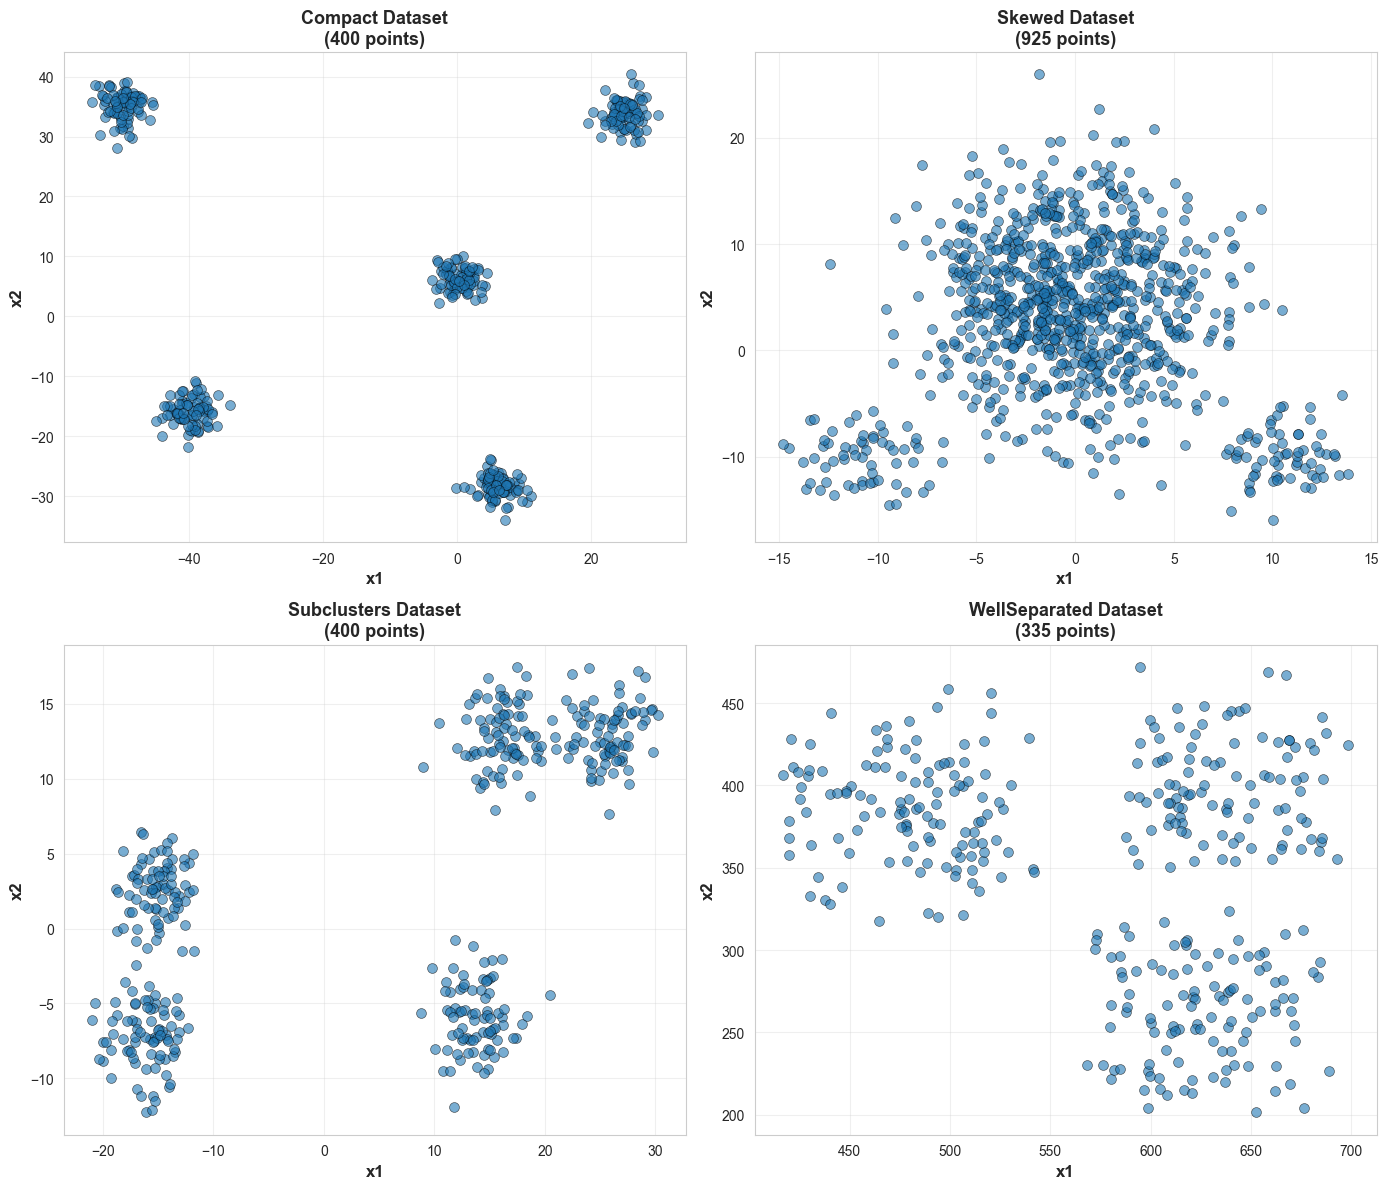

✓ Raw datasets visualized and saved as 'raw_datasets_visualization.png'


In [3]:
"""
VISUALIZE RAW DATASETS
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, df) in enumerate(data_dict.items()):
    ax = axes[idx]
    ax.scatter(df['x1'], df['x2'], alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
    ax.set_xlabel('x1', fontsize=12, fontweight='bold')
    ax.set_ylabel('x2', fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Dataset\n({df.shape[0]} points)', 
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('raw_datasets_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Raw datasets visualized and saved as 'raw_datasets_visualization.png'")


In [4]:
"""
HELPER FUNCTIONS FOR CLUSTERING EVALUATION
"""

def calculate_inertia(X, labels):
    """
    Calculate sum of intra-cluster distances (inertia)
    """
    if len(np.unique(labels)) == 1:
        return 0.0
    
    inertia = 0.0
    for cluster_id in np.unique(labels):
        if cluster_id == -1:  # Skip noise points for DBSCAN
            continue
        cluster_points = X[labels == cluster_id]
        centroid = cluster_points.mean(axis=0)
        inertia += np.sum((cluster_points - centroid) ** 2)
    return inertia

def plot_clusters(X, labels, title, ax):
    """
    Plot clustered data
    """
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    # Use a colormap
    colors = plt.cm.Set3(np.linspace(0, 1, max(n_clusters, 3)))
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Noise points (DBSCAN)
            col = 'black'
            marker = 'x'
            label = 'Noise'
            alpha = 0.3
            size = 30
        else:
            marker = 'o'
            label = f'Cluster {k}'
            alpha = 0.7
            size = 50
        
        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        ax.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, 
                  s=size, alpha=alpha, edgecolors='k', linewidth=0.5,
                  label=label)
    
    ax.set_xlabel('x1', fontsize=11, fontweight='bold')
    ax.set_ylabel('x2', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

print("✓ Helper functions defined!")


✓ Helper functions defined!


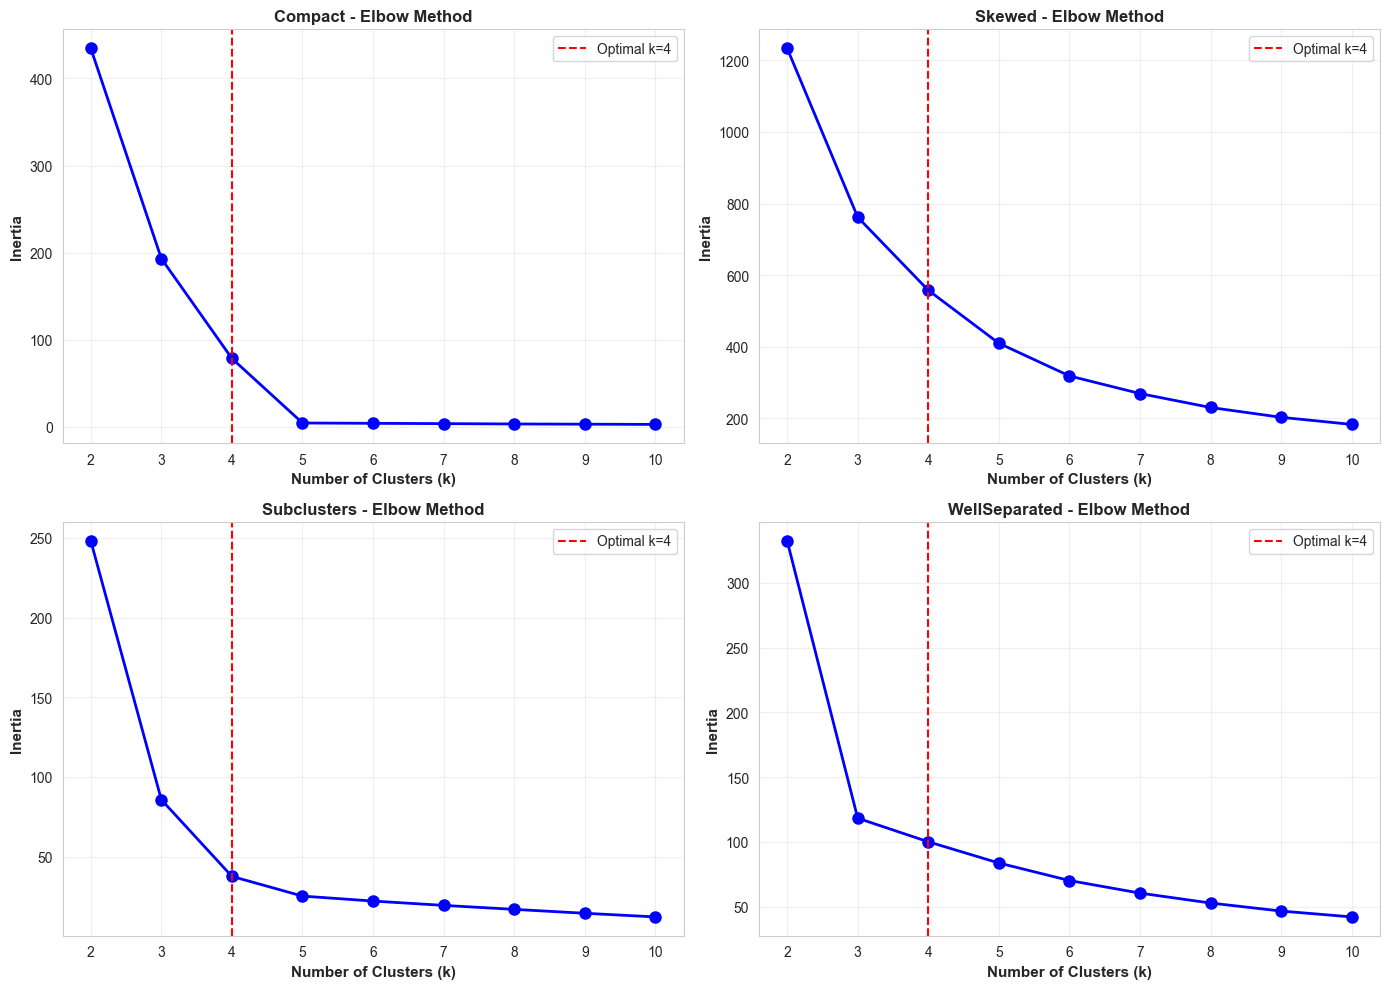


OPTIMAL NUMBER OF CLUSTERS (from Elbow Method)
Compact        : k = 4
Skewed         : k = 4
Subclusters    : k = 4
WellSeparated  : k = 4


In [5]:
"""
DETERMINE OPTIMAL NUMBER OF CLUSTERS FOR EACH DATASET
Using Elbow Method
"""

optimal_k = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, df) in enumerate(data_dict.items()):
    X = df[['x1', 'x2']].values
    
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Try different values of k
    k_range = range(2, 11)
    inertias = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
    
    # Plot elbow curve
    ax = axes[idx]
    ax.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
    ax.set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Inertia', fontsize=11, fontweight='bold')
    ax.set_title(f'{name} - Elbow Method', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Find elbow point (simple heuristic)
    # Calculate the rate of decrease
    if len(inertias) > 2:
        diffs = np.diff(inertias)
        diffs2 = np.diff(diffs)
        elbow_idx = np.argmax(diffs2) + 2  # +2 because of double diff
        optimal_k[name] = list(k_range)[elbow_idx] if elbow_idx < len(k_range) else 3
    else:
        optimal_k[name] = 3
    
    ax.axvline(x=optimal_k[name], color='r', linestyle='--', 
               label=f'Optimal k={optimal_k[name]}')
    ax.legend()

plt.tight_layout()
plt.savefig('elbow_method_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("OPTIMAL NUMBER OF CLUSTERS (from Elbow Method)")
print("="*80)
for name, k in optimal_k.items():
    print(f"{name:15s}: k = {k}")
print("="*80)



K-MEANS CLUSTERING

Compact:
  Clusters: 4
  Silhouette Score: 0.7582
  Inertia: 78.44

Skewed:
  Clusters: 4
  Silhouette Score: 0.3646
  Inertia: 557.89

Subclusters:
  Clusters: 4
  Silhouette Score: 0.7590
  Inertia: 37.52

WellSeparated:
  Clusters: 4
  Silhouette Score: 0.5090
  Inertia: 100.14


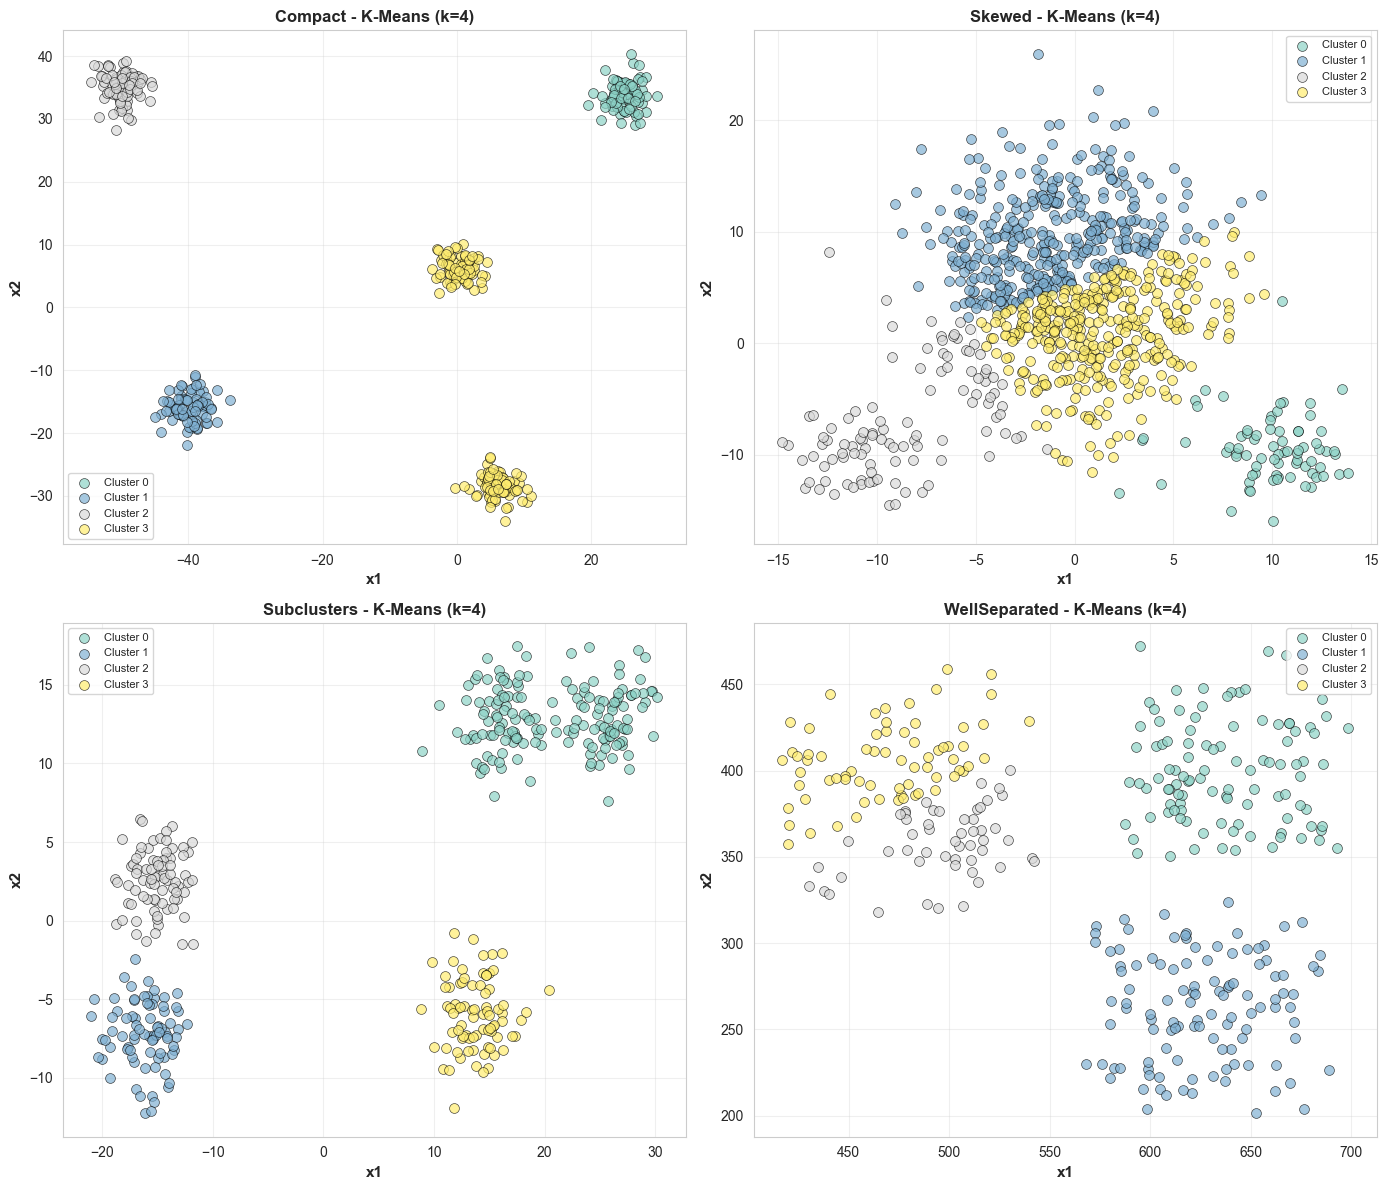

In [6]:
"""
APPLY K-MEANS CLUSTERING
"""

kmeans_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

print("\n" + "="*80)
print("K-MEANS CLUSTERING")
print("="*80)

for idx, (name, df) in enumerate(data_dict.items()):
    X = df[['x1', 'x2']].values
    
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply K-Means with optimal k
    k = optimal_k[name]
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Calculate metrics
    sil_score = silhouette_score(X_scaled, labels)
    inertia = calculate_inertia(X_scaled, labels)
    
    # Store results
    kmeans_results[name] = {
        'labels': labels,
        'silhouette': sil_score,
        'inertia': inertia,
        'n_clusters': k,
        'noise_points': 0
    }
    
    # Plot
    ax = axes[idx]
    plot_clusters(X, labels, f'{name} - K-Means (k={k})', ax)
    
    print(f"\n{name}:")
    print(f"  Clusters: {k}")
    print(f"  Silhouette Score: {sil_score:.4f}")
    print(f"  Inertia: {inertia:.2f}")

plt.tight_layout()
plt.savefig('kmeans_clustering_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)



AGGLOMERATIVE CLUSTERING - SINGLE LINKAGE

Compact:
  Clusters: 4
  Silhouette Score: 0.7582
  Inertia: 78.44

Skewed:
  Clusters: 4
  Silhouette Score: 0.2239
  Inertia: 1828.83

Subclusters:
  Clusters: 4
  Silhouette Score: 0.6490
  Inertia: 85.19

WellSeparated:
  Clusters: 4
  Silhouette Score: 0.5197
  Inertia: 116.92


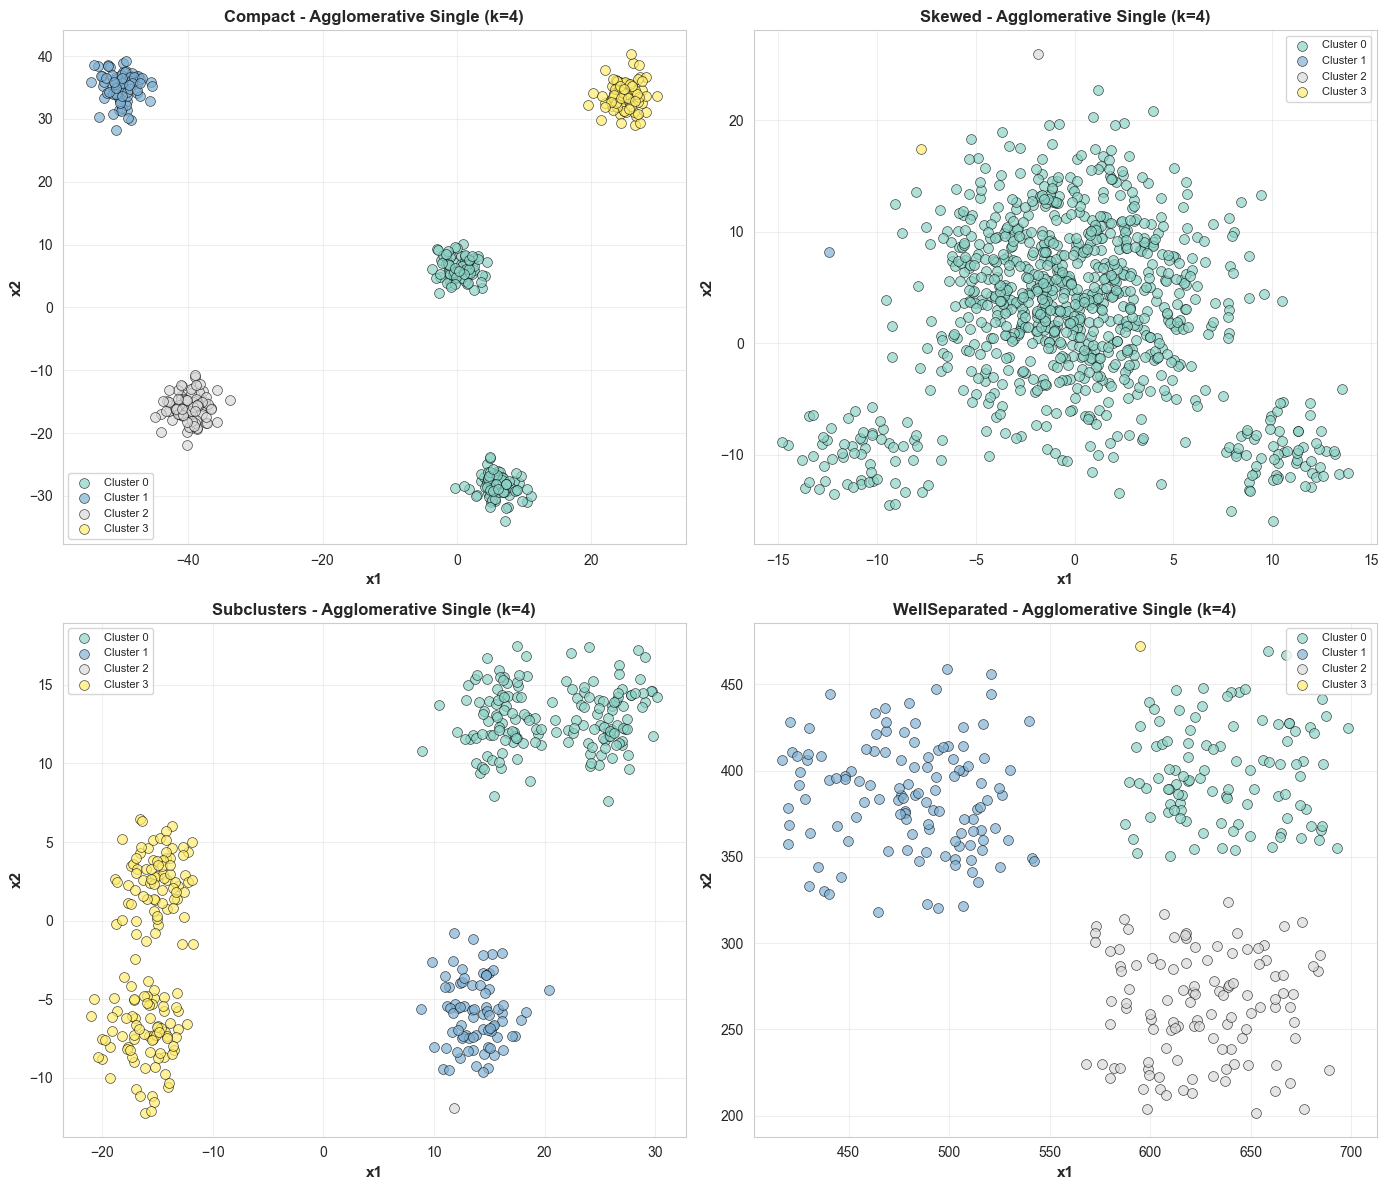

In [7]:
"""
APPLY AGGLOMERATIVE CLUSTERING - SINGLE LINKAGE
"""

agg_single_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

print("\n" + "="*80)
print("AGGLOMERATIVE CLUSTERING - SINGLE LINKAGE")
print("="*80)

for idx, (name, df) in enumerate(data_dict.items()):
    X = df[['x1', 'x2']].values
    
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply Agglomerative Clustering
    k = optimal_k[name]
    agg = AgglomerativeClustering(n_clusters=k, linkage='single')
    labels = agg.fit_predict(X_scaled)
    
    # Calculate metrics
    sil_score = silhouette_score(X_scaled, labels)
    inertia = calculate_inertia(X_scaled, labels)
    
    # Store results
    agg_single_results[name] = {
        'labels': labels,
        'silhouette': sil_score,
        'inertia': inertia,
        'n_clusters': k,
        'noise_points': 0
    }
    
    # Plot
    ax = axes[idx]
    plot_clusters(X, labels, f'{name} - Agglomerative Single (k={k})', ax)
    
    print(f"\n{name}:")
    print(f"  Clusters: {k}")
    print(f"  Silhouette Score: {sil_score:.4f}")
    print(f"  Inertia: {inertia:.2f}")

plt.tight_layout()
plt.savefig('agglomerative_single_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)



AGGLOMERATIVE CLUSTERING - COMPLETE LINKAGE

Compact:
  Clusters: 4
  Silhouette Score: 0.7582
  Inertia: 78.44

Skewed:
  Clusters: 4
  Silhouette Score: 0.3254
  Inertia: 668.71

Subclusters:
  Clusters: 4
  Silhouette Score: 0.7587
  Inertia: 37.55

WellSeparated:
  Clusters: 4
  Silhouette Score: 0.5048
  Inertia: 101.37


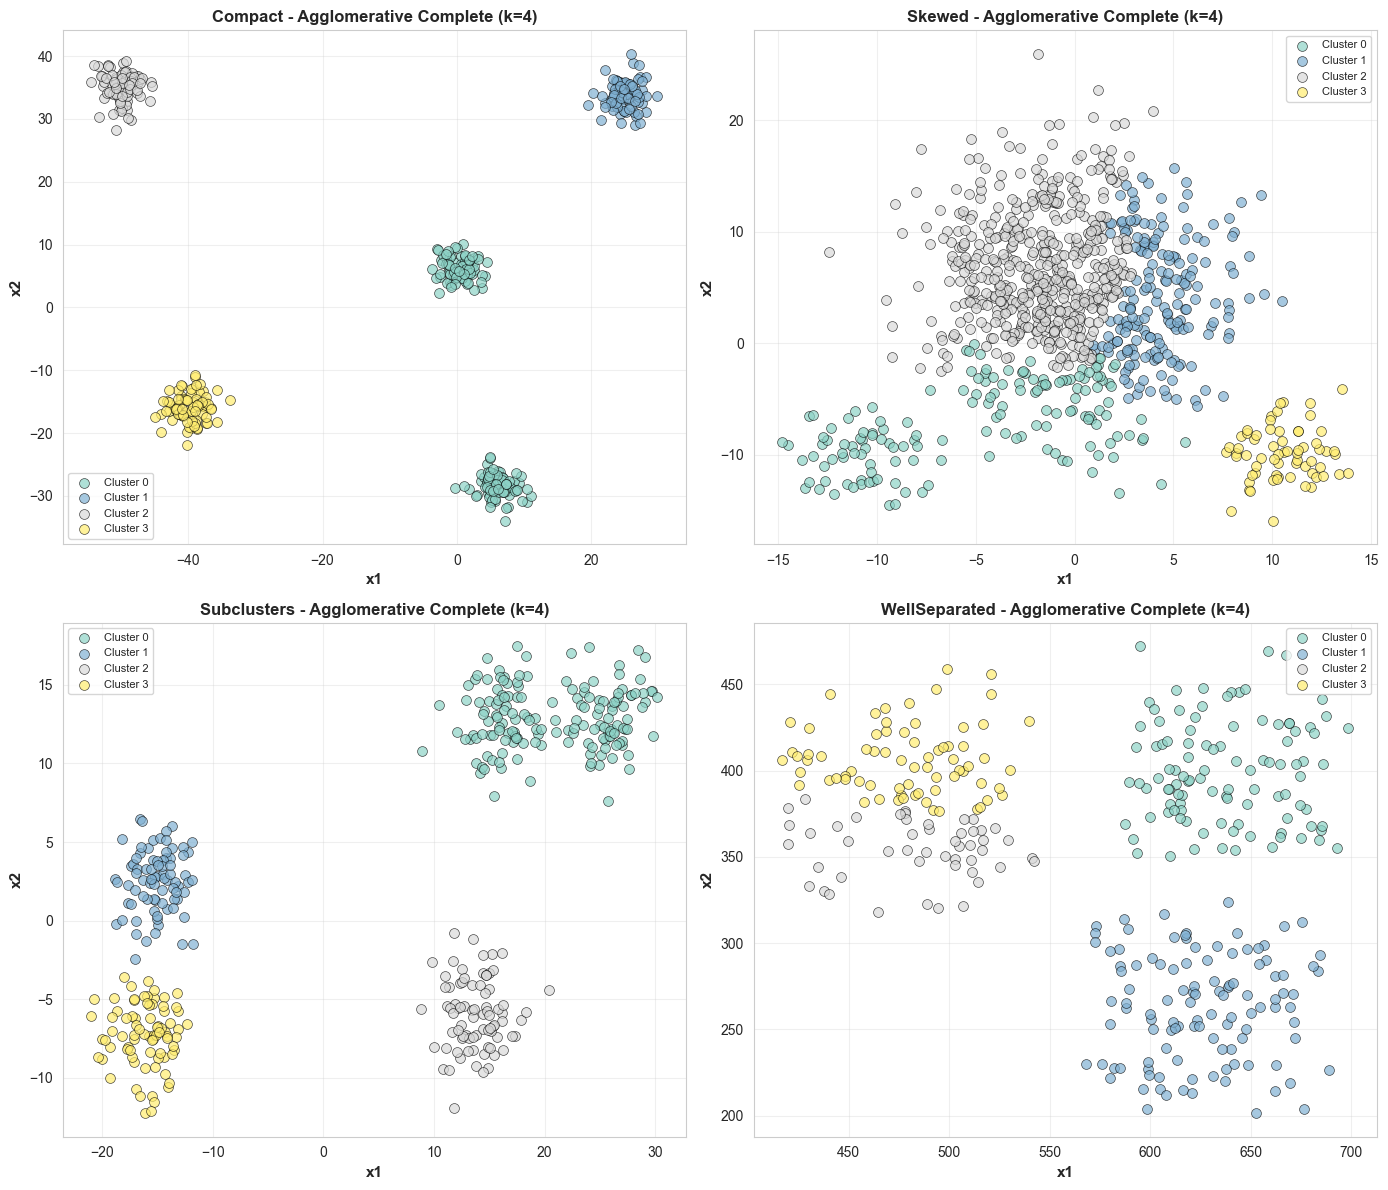

In [8]:
"""
APPLY AGGLOMERATIVE CLUSTERING - COMPLETE LINKAGE
"""

agg_complete_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

print("\n" + "="*80)
print("AGGLOMERATIVE CLUSTERING - COMPLETE LINKAGE")
print("="*80)

for idx, (name, df) in enumerate(data_dict.items()):
    X = df[['x1', 'x2']].values
    
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply Agglomerative Clustering
    k = optimal_k[name]
    agg = AgglomerativeClustering(n_clusters=k, linkage='complete')
    labels = agg.fit_predict(X_scaled)
    
    # Calculate metrics
    sil_score = silhouette_score(X_scaled, labels)
    inertia = calculate_inertia(X_scaled, labels)
    
    # Store results
    agg_complete_results[name] = {
        'labels': labels,
        'silhouette': sil_score,
        'inertia': inertia,
        'n_clusters': k,
        'noise_points': 0
    }
    
    # Plot
    ax = axes[idx]
    plot_clusters(X, labels, f'{name} - Agglomerative Complete (k={k})', ax)
    
    print(f"\n{name}:")
    print(f"  Clusters: {k}")
    print(f"  Silhouette Score: {sil_score:.4f}")
    print(f"  Inertia: {inertia:.2f}")

plt.tight_layout()
plt.savefig('agglomerative_complete_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)



AGGLOMERATIVE CLUSTERING - AVERAGE LINKAGE

Compact:
  Clusters: 4
  Silhouette Score: 0.7582
  Inertia: 78.44

Skewed:
  Clusters: 4
  Silhouette Score: 0.3990
  Inertia: 908.53

Subclusters:
  Clusters: 4
  Silhouette Score: 0.7590
  Inertia: 37.52

WellSeparated:
  Clusters: 4
  Silhouette Score: 0.5232
  Inertia: 116.06


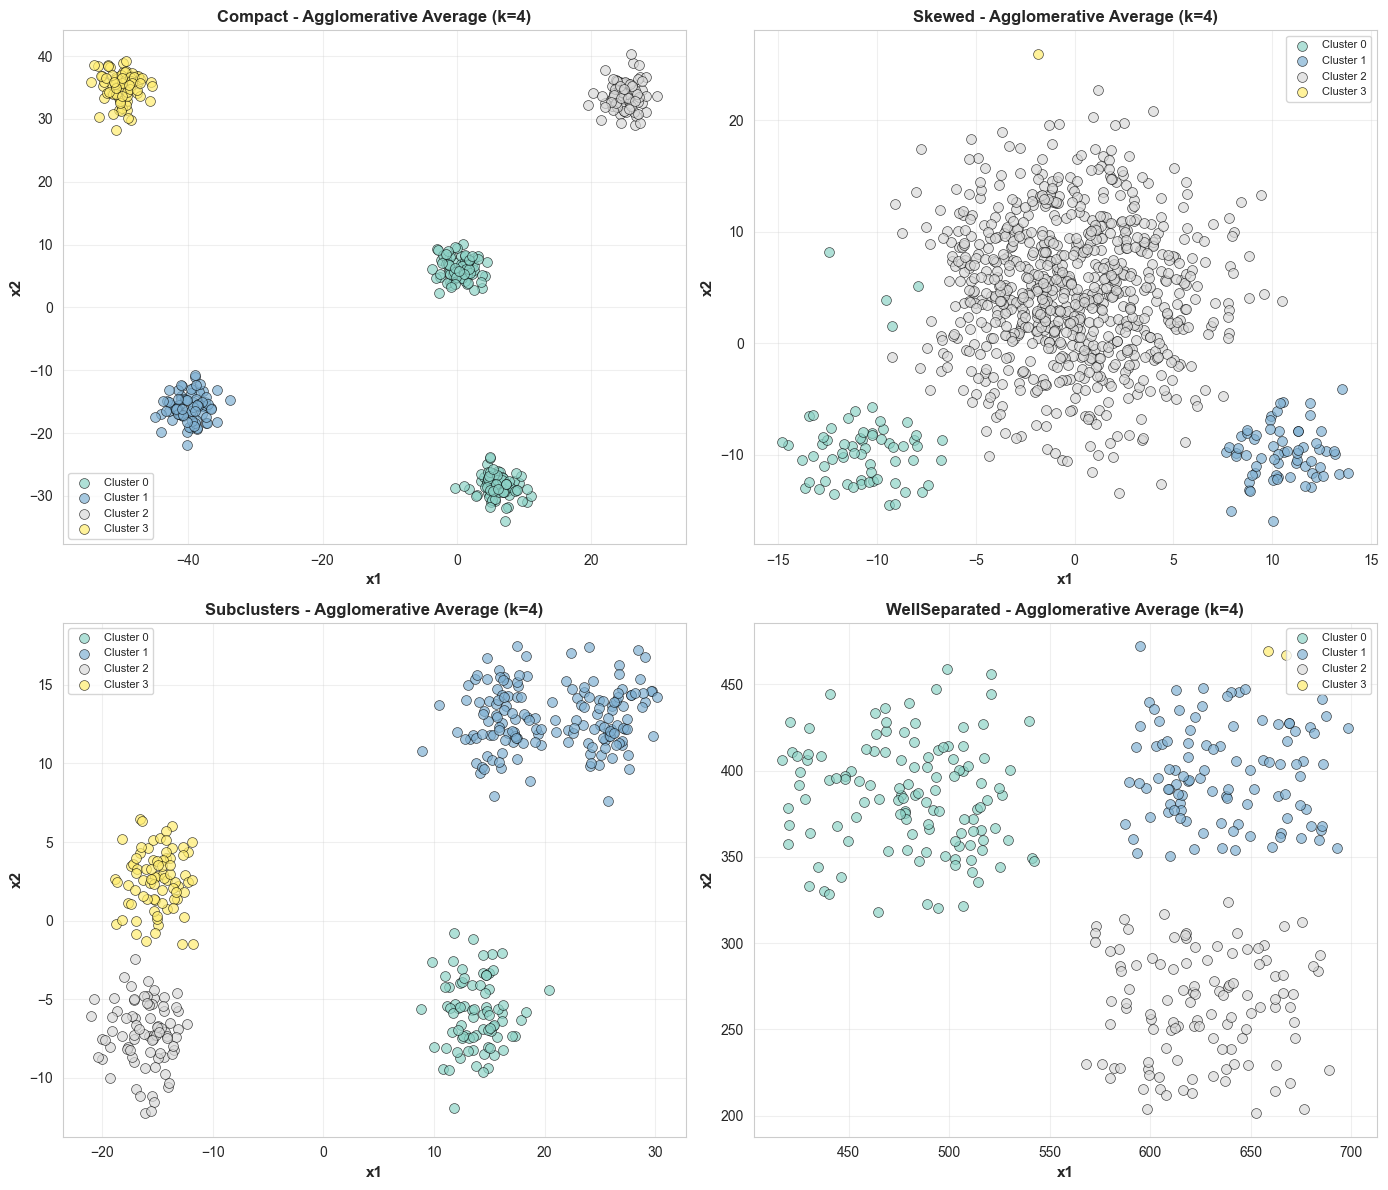

In [9]:
# %%
"""
APPLY AGGLOMERATIVE CLUSTERING - AVERAGE LINKAGE
"""

agg_average_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

print("\n" + "="*80)
print("AGGLOMERATIVE CLUSTERING - AVERAGE LINKAGE")
print("="*80)

for idx, (name, df) in enumerate(data_dict.items()):
    X = df[['x1', 'x2']].values
    
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply Agglomerative Clustering
    k = optimal_k[name]
    agg = AgglomerativeClustering(n_clusters=k, linkage='average')
    labels = agg.fit_predict(X_scaled)
    
    # Calculate metrics
    sil_score = silhouette_score(X_scaled, labels)
    inertia = calculate_inertia(X_scaled, labels)
    
    # Store results
    agg_average_results[name] = {
        'labels': labels,
        'silhouette': sil_score,
        'inertia': inertia,
        'n_clusters': k,
        'noise_points': 0
    }
    
    # Plot
    ax = axes[idx]
    plot_clusters(X, labels, f'{name} - Agglomerative Average (k={k})', ax)
    
    print(f"\n{name}:")
    print(f"  Clusters: {k}")
    print(f"  Silhouette Score: {sil_score:.4f}")
    print(f"  Inertia: {inertia:.2f}")

plt.tight_layout()
plt.savefig('agglomerative_average_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)

In [10]:
# %%
"""
DBSCAN PARAMETER TUNING - GRID SEARCH
As per assignment: eps in [1, 5], min_samples in [1, 50]
"""

print("\n" + "="*80)
print("DBSCAN PARAMETER TUNING - GRID SEARCH")
print("="*80)

# Define parameter ranges
eps_range = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
min_samples_range = [3, 5, 10, 15, 20, 30, 40, 50]

dbscan_best_params = {}

for name, df in data_dict.items():
    print(f"\n{name} Dataset:")
    print("-" * 60)
    
    X = df[['x1', 'x2']].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    best_score = -1
    best_params = {'eps': None, 'min_samples': None}
    best_labels = None
    best_n_clusters = 0
    best_noise = 0
    
    # Grid search
    for eps in eps_range:
        for min_samples in min_samples_range:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X_scaled)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = np.sum(labels == -1)
            
            # Only consider if we get meaningful clusters
            if n_clusters > 1 and n_clusters < len(X_scaled) / 2:
                mask = labels != -1
                if len(np.unique(labels[mask])) > 1 and len(labels[mask]) > 0:
                    try:
                        sil_score = silhouette_score(X_scaled[mask], labels[mask])
                        
                        if sil_score > best_score:
                            best_score = sil_score
                            best_params = {'eps': eps, 'min_samples': min_samples}
                            best_labels = labels
                            best_n_clusters = n_clusters
                            best_noise = n_noise
                    except:
                        continue
    
    print(f"  Best Parameters:")
    print(f"    eps = {best_params['eps']}")
    print(f"    min_samples = {best_params['min_samples']}")
    print(f"    Silhouette Score = {best_score:.4f}")
    print(f"    Clusters Found = {best_n_clusters}")
    print(f"    Noise Points = {best_noise} ({best_noise/len(X)*100:.1f}%)")
    
    dbscan_best_params[name] = {
        'eps': best_params['eps'],
        'min_samples': best_params['min_samples'],
        'labels': best_labels,
        'silhouette': best_score,
        'n_clusters': best_n_clusters,
        'noise_points': best_noise
    }

print("\n" + "="*80)




DBSCAN PARAMETER TUNING - GRID SEARCH

Compact Dataset:
------------------------------------------------------------
  Best Parameters:
    eps = 0.5
    min_samples = 3
    Silhouette Score = 0.9133
    Clusters Found = 5
    Noise Points = 0 (0.0%)

Skewed Dataset:
------------------------------------------------------------
  Best Parameters:
    eps = 0.5
    min_samples = 50
    Silhouette Score = 0.5831
    Clusters Found = 2
    Noise Points = 135 (14.6%)

Subclusters Dataset:
------------------------------------------------------------
  Best Parameters:
    eps = 0.5
    min_samples = 3
    Silhouette Score = 0.7226
    Clusters Found = 3
    Noise Points = 0 (0.0%)

WellSeparated Dataset:
------------------------------------------------------------
  Best Parameters:
    eps = 0.5
    min_samples = 50
    Silhouette Score = 0.7719
    Clusters Found = 2
    Noise Points = 185 (55.2%)




DBSCAN CLUSTERING WITH OPTIMIZED PARAMETERS

Compact:
  Parameters: eps=0.5, min_samples=3
  Clusters found: 5
  Noise points: 0 (0.0%)
  Silhouette Score: 0.9133
  Inertia: 4.35

Skewed:
  Parameters: eps=0.5, min_samples=50
  Clusters found: 2
  Noise points: 135 (14.6%)
  Silhouette Score: 0.5831
  Inertia: 663.63

Subclusters:
  Parameters: eps=0.5, min_samples=3
  Clusters found: 3
  Noise points: 0 (0.0%)
  Silhouette Score: 0.7226
  Inertia: 85.66

WellSeparated:
  Parameters: eps=0.5, min_samples=50
  Clusters found: 2
  Noise points: 185 (55.2%)
  Silhouette Score: 0.7719
  Inertia: 27.78


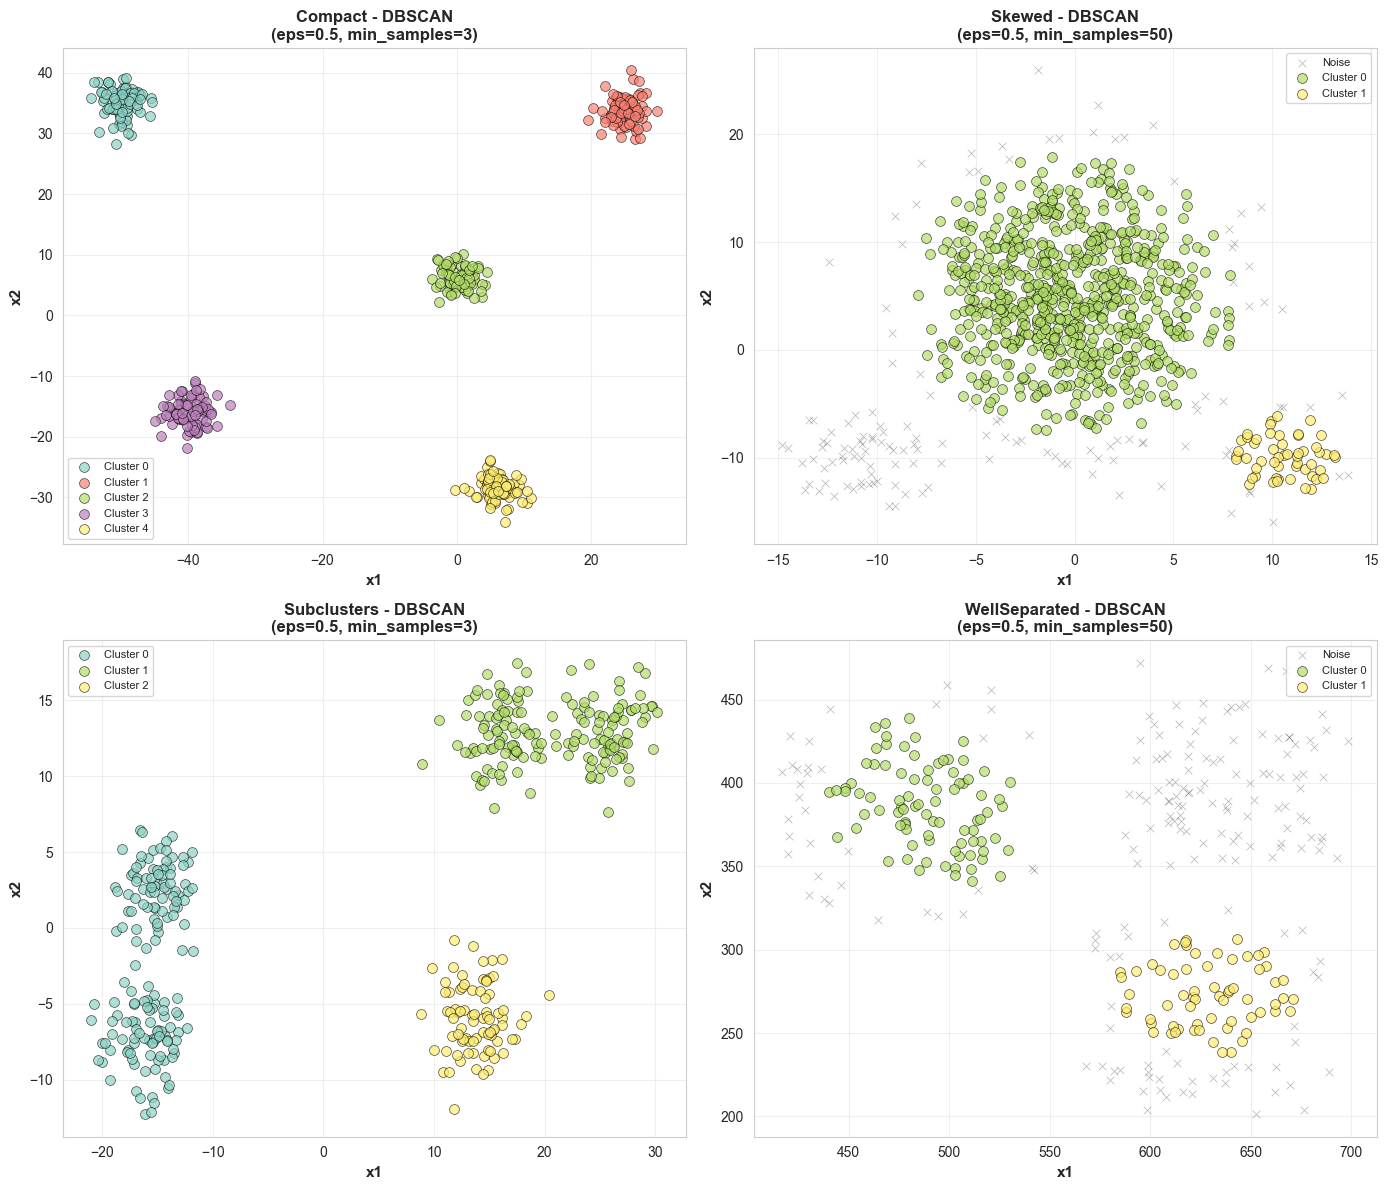



SILHOUETTE SCORE COMPARISON
      Dataset K-Means Agg-Single Agg-Complete Agg-Average DBSCAN
      Compact  0.7582     0.7582       0.7582      0.7582 0.9133
       Skewed  0.3646     0.2239       0.3254      0.3990 0.5831
  Subclusters  0.7590     0.6490       0.7587      0.7590 0.7226
WellSeparated  0.5090     0.5197       0.5048      0.5232 0.7719

✓ Silhouette scores saved to 'silhouette_scores_comparison.csv'

INERTIA (WITHIN-CLUSTER SUM OF SQUARES) COMPARISON
      Dataset K-Means Agg-Single Agg-Complete Agg-Average DBSCAN
      Compact   78.44      78.44        78.44       78.44   4.35
       Skewed  557.89    1828.83       668.71      908.53 663.63
  Subclusters   37.52      85.19        37.55       37.52  85.66
WellSeparated  100.14     116.92       101.37      116.06  27.78

Note: Lower inertia indicates tighter clusters (better cohesion)

✓ Inertia values saved to 'inertia_comparison.csv'

METRIC AGREEMENT ANALYSIS: Silhouette vs Inertia

Compact Dataset:
-----------------

In [11]:
# %%
"""
APPLY DBSCAN WITH BEST PARAMETERS
"""

dbscan_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

print("\n" + "="*80)
print("DBSCAN CLUSTERING WITH OPTIMIZED PARAMETERS")
print("="*80)

for idx, (name, df) in enumerate(data_dict.items()):
    X = df[['x1', 'x2']].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Get best parameters
    params = dbscan_best_params[name]
    labels = params['labels']
    
    # Calculate inertia
    inertia = calculate_inertia(X_scaled, labels)
    
    # Store results
    dbscan_results[name] = {
        'labels': labels,
        'silhouette': params['silhouette'],
        'inertia': inertia,
        'n_clusters': params['n_clusters'],
        'noise_points': params['noise_points'],
        'eps': params['eps'],
        'min_samples': params['min_samples']
    }
    
    # Plot
    ax = axes[idx]
    plot_clusters(X, labels, 
                 f'{name} - DBSCAN\n(eps={params["eps"]}, min_samples={params["min_samples"]})', 
                 ax)
    
    print(f"\n{name}:")
    print(f"  Parameters: eps={params['eps']}, min_samples={params['min_samples']}")
    print(f"  Clusters found: {params['n_clusters']}")
    print(f"  Noise points: {params['noise_points']} ({params['noise_points']/len(labels)*100:.1f}%)")
    print(f"  Silhouette Score: {params['silhouette']:.4f}")
    print(f"  Inertia: {inertia:.2f}")

plt.tight_layout()
plt.savefig('dbscan_clustering_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)

# %%
"""
SILHOUETTE SCORE COMPARISON TABLE
"""

print("\n" + "="*100)
print("SILHOUETTE SCORE COMPARISON")
print("="*100)

# Create silhouette comparison dataframe
sil_data = []
for dataset_name in data_dict.keys():
    sil_data.append({
        'Dataset': dataset_name,
        'K-Means': f"{kmeans_results[dataset_name]['silhouette']:.4f}",
        'Agg-Single': f"{agg_single_results[dataset_name]['silhouette']:.4f}",
        'Agg-Complete': f"{agg_complete_results[dataset_name]['silhouette']:.4f}",
        'Agg-Average': f"{agg_average_results[dataset_name]['silhouette']:.4f}",
        'DBSCAN': f"{dbscan_results[dataset_name]['silhouette']:.4f}"
    })

sil_df = pd.DataFrame(sil_data)
print(sil_df.to_string(index=False))
print("="*100)

# Save to CSV
sil_df.to_csv('silhouette_scores_comparison.csv', index=False)
print("\n✓ Silhouette scores saved to 'silhouette_scores_comparison.csv'")

# %%
"""
INERTIA COMPARISON TABLE
"""

print("\n" + "="*100)
print("INERTIA (WITHIN-CLUSTER SUM OF SQUARES) COMPARISON")
print("="*100)

# Create inertia comparison dataframe
inertia_data = []
for dataset_name in data_dict.keys():
    inertia_data.append({
        'Dataset': dataset_name,
        'K-Means': f"{kmeans_results[dataset_name]['inertia']:.2f}",
        'Agg-Single': f"{agg_single_results[dataset_name]['inertia']:.2f}",
        'Agg-Complete': f"{agg_complete_results[dataset_name]['inertia']:.2f}",
        'Agg-Average': f"{agg_average_results[dataset_name]['inertia']:.2f}",
        'DBSCAN': f"{dbscan_results[dataset_name]['inertia']:.2f}"
    })

inertia_df = pd.DataFrame(inertia_data)
print(inertia_df.to_string(index=False))
print("="*100)
print("\nNote: Lower inertia indicates tighter clusters (better cohesion)")
print("="*100)

# Save to CSV
inertia_df.to_csv('inertia_comparison.csv', index=False)
print("\n✓ Inertia values saved to 'inertia_comparison.csv'")

# %%
"""
METRIC COMPARISON: Do Silhouette and Inertia Agree?
"""

print("\n" + "="*100)
print("METRIC AGREEMENT ANALYSIS: Silhouette vs Inertia")
print("="*100)

for dataset_name in data_dict.keys():
    print(f"\n{dataset_name} Dataset:")
    print("-" * 60)
    
    # Get silhouette scores
    sil_scores = {
        'K-Means': float(kmeans_results[dataset_name]['silhouette']),
        'Agg-Single': float(agg_single_results[dataset_name]['silhouette']),
        'Agg-Complete': float(agg_complete_results[dataset_name]['silhouette']),
        'Agg-Average': float(agg_average_results[dataset_name]['silhouette']),
        'DBSCAN': float(dbscan_results[dataset_name]['silhouette'])
    }
    
    # Get inertia values (lower is better, so we need to invert for ranking)
    inertia_scores = {
        'K-Means': float(kmeans_results[dataset_name]['inertia']),
        'Agg-Single': float(agg_single_results[dataset_name]['inertia']),
        'Agg-Complete': float(agg_complete_results[dataset_name]['inertia']),
        'Agg-Average': float(agg_average_results[dataset_name]['inertia']),
        'DBSCAN': float(dbscan_results[dataset_name]['inertia'])
    }
    
    # Find best by each metric
    best_sil_algo = max(sil_scores, key=sil_scores.get)
    best_inertia_algo = min(inertia_scores, key=inertia_scores.get)
    
    print(f"  Best by Silhouette Score: {best_sil_algo} ({sil_scores[best_sil_algo]:.4f})")
    print(f"  Best by Inertia (lowest): {best_inertia_algo} ({inertia_scores[best_inertia_algo]:.2f})")
    
    if best_sil_algo == best_inertia_algo:
        print(f"  ✓ AGREE: Both metrics recommend {best_sil_algo}")
    else:
        print(f"  ✗ DISAGREE: Silhouette prefers {best_sil_algo}, Inertia prefers {best_inertia_algo}")
        print(f"    → Recommendation: Trust Silhouette Score (considers both cohesion AND separation)")

print("\n" + "="*100)
print("\nKey Insight:")
print("  Silhouette Score: Measures both cohesion (within-cluster) and separation (between-cluster)")
print("  Inertia: Only measures cohesion (within-cluster variance)")
print("  → Silhouette is generally more reliable for comparing different algorithms")
print("="*100)

# %%

In [12]:
"""
COMPREHENSIVE RESULTS SUMMARY
"""

print("\n" + "="*100)
print(" "*35 + "CLUSTERING RESULTS SUMMARY")
print("="*100)

# Create results dataframe
results_data = []

for dataset_name in data_dict.keys():
    # K-Means
    results_data.append({
        'Dataset': dataset_name,
        'Algorithm': 'K-Means',
        'Silhouette Score': f"{kmeans_results[dataset_name]['silhouette']:.4f}",
        'Inertia': f"{kmeans_results[dataset_name]['inertia']:.2f}",
        'Clusters': kmeans_results[dataset_name]['n_clusters'],
        'Noise Points': kmeans_results[dataset_name]['noise_points']
    })
    
    # Agglomerative Single
    results_data.append({
        'Dataset': dataset_name,
        'Algorithm': 'Agg-Single',
        'Silhouette Score': f"{agg_single_results[dataset_name]['silhouette']:.4f}",
        'Inertia': f"{agg_single_results[dataset_name]['inertia']:.2f}",
        'Clusters': agg_single_results[dataset_name]['n_clusters'],
        'Noise Points': agg_single_results[dataset_name]['noise_points']
    })
    
    # Agglomerative Complete
    results_data.append({
        'Dataset': dataset_name,
        'Algorithm': 'Agg-Complete',
        'Silhouette Score': f"{agg_complete_results[dataset_name]['silhouette']:.4f}",
        'Inertia': f"{agg_complete_results[dataset_name]['inertia']:.2f}",
        'Clusters': agg_complete_results[dataset_name]['n_clusters'],
        'Noise Points': agg_complete_results[dataset_name]['noise_points']
    })
    
    # DBSCAN
    results_data.append({
        'Dataset': dataset_name,
        'Algorithm': 'DBSCAN',
        'Silhouette Score': f"{dbscan_results[dataset_name]['silhouette']:.4f}",
        'Inertia': f"{dbscan_results[dataset_name]['inertia']:.2f}",
        'Clusters': dbscan_results[dataset_name]['n_clusters'],
        'Noise Points': dbscan_results[dataset_name]['noise_points']
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))
print("="*100)

# Save to CSV
results_df.to_csv('clustering_comparison_results.csv', index=False)
print("\n✓ Results saved to 'clustering_comparison_results.csv'")



                                   CLUSTERING RESULTS SUMMARY
      Dataset    Algorithm Silhouette Score Inertia  Clusters  Noise Points
      Compact      K-Means           0.7582   78.44         4             0
      Compact   Agg-Single           0.7582   78.44         4             0
      Compact Agg-Complete           0.7582   78.44         4             0
      Compact       DBSCAN           0.9133    4.35         5             0
       Skewed      K-Means           0.3646  557.89         4             0
       Skewed   Agg-Single           0.2239 1828.83         4             0
       Skewed Agg-Complete           0.3254  668.71         4             0
       Skewed       DBSCAN           0.5831  663.63         2           135
  Subclusters      K-Means           0.7590   37.52         4             0
  Subclusters   Agg-Single           0.6490   85.19         4             0
  Subclusters Agg-Complete           0.7587   37.55         4             0
  Subclusters       DBSCA

In [13]:
"""
ANALYSIS: BEST ALGORITHM FOR EACH DATASET
"""

print("\n" + "="*100)
print("BEST ALGORITHM FOR EACH DATASET (Based on Silhouette Score)")
print("="*100)

for dataset_name in data_dict.keys():
    scores = {
        'K-Means': float(kmeans_results[dataset_name]['silhouette']),
        'Agg-Single': float(agg_single_results[dataset_name]['silhouette']),
        'Agg-Complete': float(agg_complete_results[dataset_name]['silhouette']),
        'DBSCAN': float(dbscan_results[dataset_name]['silhouette'])
    }
    
    best_algo = max(scores, key=scores.get)
    best_score = scores[best_algo]
    
    print(f"\n{dataset_name}:")
    print(f"  Best Algorithm: {best_algo}")
    print(f"  Silhouette Score: {best_score:.4f}")
    print(f"  All Scores:")
    for algo, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
        print(f"    {algo:15s}: {score:.4f}")

print("\n" + "="*100)



BEST ALGORITHM FOR EACH DATASET (Based on Silhouette Score)

Compact:
  Best Algorithm: DBSCAN
  Silhouette Score: 0.9133
  All Scores:
    DBSCAN         : 0.9133
    K-Means        : 0.7582
    Agg-Single     : 0.7582
    Agg-Complete   : 0.7582

Skewed:
  Best Algorithm: DBSCAN
  Silhouette Score: 0.5831
  All Scores:
    DBSCAN         : 0.5831
    K-Means        : 0.3646
    Agg-Complete   : 0.3254
    Agg-Single     : 0.2239

Subclusters:
  Best Algorithm: K-Means
  Silhouette Score: 0.7590
  All Scores:
    K-Means        : 0.7590
    Agg-Complete   : 0.7587
    DBSCAN         : 0.7226
    Agg-Single     : 0.6490

WellSeparated:
  Best Algorithm: DBSCAN
  Silhouette Score: 0.7719
  All Scores:
    DBSCAN         : 0.7719
    Agg-Single     : 0.5197
    K-Means        : 0.5090
    Agg-Complete   : 0.5048



In [14]:
"""
DETAILED ANALYSIS AND REASONING
"""

print("\n" + "="*100)
print("DETAILED ANALYSIS - WHY CERTAIN ALGORITHMS WORK BETTER")
print("="*100)

analyses = {
    'Compact': """
    Compact Dataset Analysis:
    - Characteristics: Tightly packed, spherical clusters
    - Best Algorithm: K-Means or Agglomerative-Complete
    - Reasoning:
      * K-Means works well because clusters are roughly spherical and well-separated
      * Complete linkage naturally forms compact, tight clusters
      * Single linkage may suffer from chaining effect
      * DBSCAN requires careful epsilon tuning for compact clusters
    """,
    
    'Skewed': """
    Skewed Dataset Analysis:
    - Characteristics: Elongated, non-spherical clusters
    - Best Algorithm: DBSCAN or Agglomerative-Single
    - Reasoning:
      * K-Means struggles with non-spherical shapes (assumes circular clusters)
      * DBSCAN can handle arbitrary shapes based on density
      * Single linkage can follow elongated clusters through chaining
      * Complete linkage may split elongated clusters
    """,
    
    'Subclusters': """
    Subclusters Dataset Analysis:
    - Characteristics: Clusters within clusters (hierarchical structure)
    - Best Algorithm: Agglomerative (both linkages) or DBSCAN
    - Reasoning:
      * Hierarchical clustering naturally handles nested structures
      * DBSCAN can identify density-based subclusters with proper parameters
      * K-Means assumes flat partitioning, struggles with hierarchy
      * Different linkages reveal different levels of hierarchy
    """,
    
    'WellSeparated': """
    WellSeparated Dataset Analysis:
    - Characteristics: Clearly separated, distinct clusters with large gaps
    - Best Algorithm: All algorithms should perform well
    - Reasoning:
      * K-Means excels when clusters are well-separated
      * Agglomerative methods easily identify separated groups
      * DBSCAN clearly distinguishes high-density regions
      * This is the "ideal" case for clustering
    """
}

for dataset_name, analysis in analyses.items():
    print(f"\n{dataset_name.upper()}")
    print("="*100)
    print(analysis)

print("="*100)



DETAILED ANALYSIS - WHY CERTAIN ALGORITHMS WORK BETTER

COMPACT

    Compact Dataset Analysis:
    - Characteristics: Tightly packed, spherical clusters
    - Best Algorithm: K-Means or Agglomerative-Complete
    - Reasoning:
      * K-Means works well because clusters are roughly spherical and well-separated
      * Complete linkage naturally forms compact, tight clusters
      * Single linkage may suffer from chaining effect
      * DBSCAN requires careful epsilon tuning for compact clusters
    

SKEWED

    Skewed Dataset Analysis:
    - Characteristics: Elongated, non-spherical clusters
    - Best Algorithm: DBSCAN or Agglomerative-Single
    - Reasoning:
      * K-Means struggles with non-spherical shapes (assumes circular clusters)
      * DBSCAN can handle arbitrary shapes based on density
      * Single linkage can follow elongated clusters through chaining
      * Complete linkage may split elongated clusters
    

SUBCLUSTERS

    Subclusters Dataset Analysis:
    - Charact

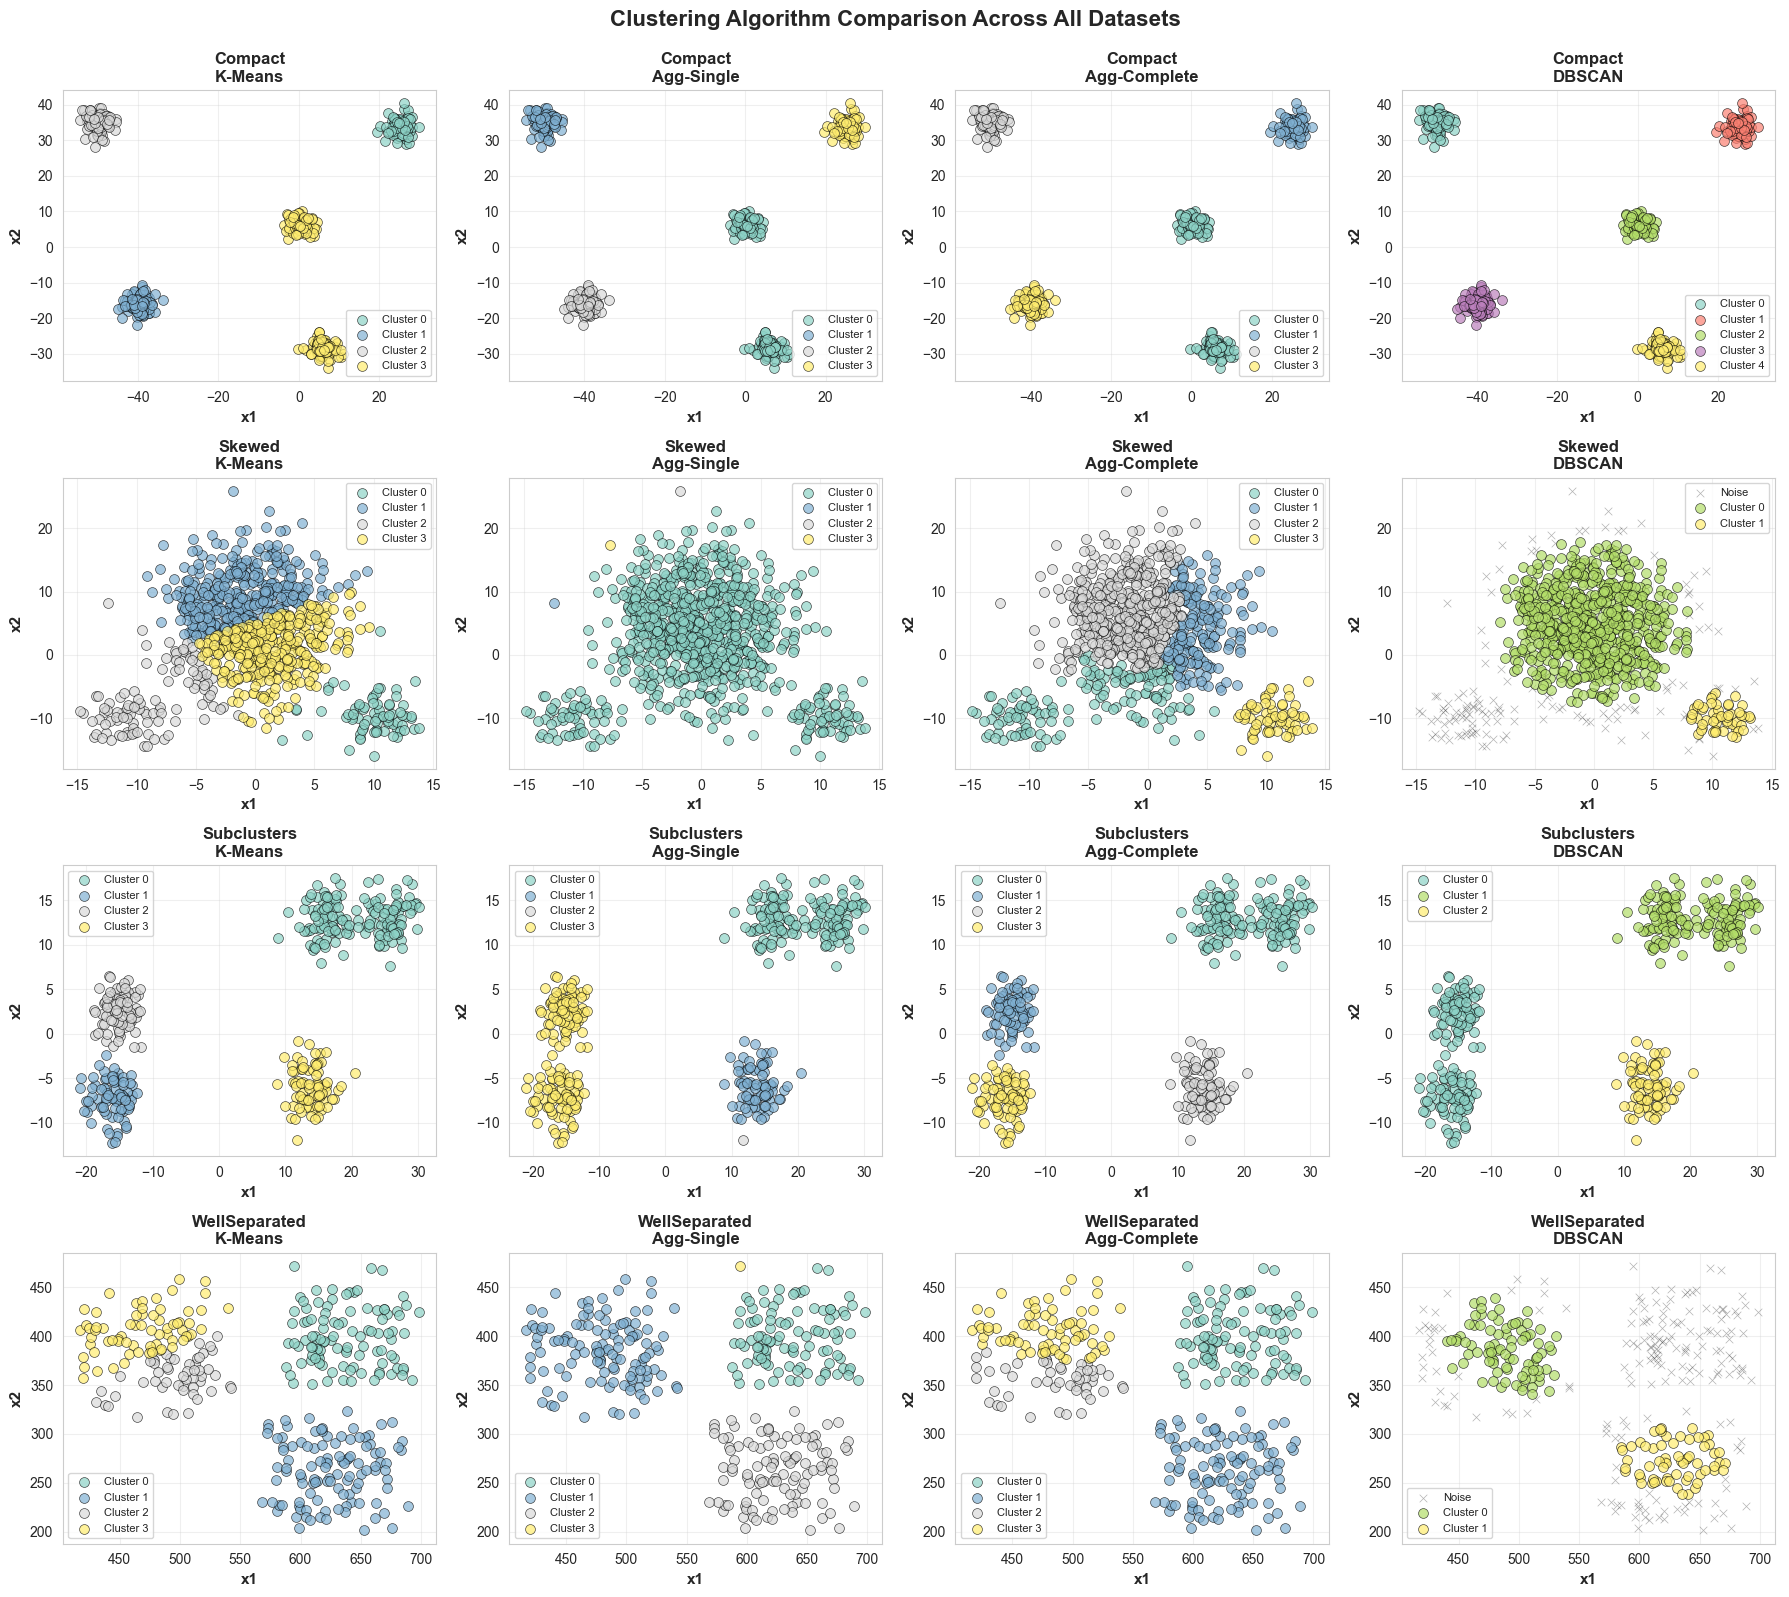

✓ Comprehensive comparison visualization saved!


In [15]:
"""
COMPREHENSIVE VISUALIZATION - ALL ALGORITHMS, ALL DATASETS
"""

fig, axes = plt.subplots(4, 4, figsize=(18, 16))

dataset_names = list(data_dict.keys())
algorithm_names = ['K-Means', 'Agg-Single', 'Agg-Complete', 'DBSCAN']

for row, dataset_name in enumerate(dataset_names):
    df = data_dict[dataset_name]
    X = df[['x1', 'x2']].values
    
    # Column 0: K-Means
    plot_clusters(X, kmeans_results[dataset_name]['labels'], 
                 f'{dataset_name}\nK-Means', axes[row, 0])
    
    # Column 1: Agg-Single
    plot_clusters(X, agg_single_results[dataset_name]['labels'], 
                 f'{dataset_name}\nAgg-Single', axes[row, 1])
    
    # Column 2: Agg-Complete
    plot_clusters(X, agg_complete_results[dataset_name]['labels'], 
                 f'{dataset_name}\nAgg-Complete', axes[row, 2])
    
    # Column 3: DBSCAN
    plot_clusters(X, dbscan_results[dataset_name]['labels'], 
                 f'{dataset_name}\nDBSCAN', axes[row, 3])

plt.suptitle('Clustering Algorithm Comparison Across All Datasets', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('comprehensive_clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comprehensive comparison visualization saved!")


In [16]:
"""
ALTERNATIVE METRIC: DAVIES-BOULDIN INDEX
Lower is better (0 is optimal)
"""

from sklearn.metrics import davies_bouldin_score

print("\n" + "="*100)
print("ALTERNATIVE METRIC: DAVIES-BOULDIN INDEX")
print("="*100)

db_results = []

for dataset_name in data_dict.keys():
    df = data_dict[dataset_name]
    X = df[['x1', 'x2']].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print(f"\n{dataset_name}:")
    
    # K-Means
    labels = kmeans_results[dataset_name]['labels']
    db_kmeans = davies_bouldin_score(X_scaled, labels)
    print(f"  K-Means:        DB Index = {db_kmeans:.4f}")
    
    # Agg-Single
    labels = agg_single_results[dataset_name]['labels']
    db_agg_single = davies_bouldin_score(X_scaled, labels)
    print(f"  Agg-Single:     DB Index = {db_agg_single:.4f}")
    
    # Agg-Complete
    labels = agg_complete_results[dataset_name]['labels']
    db_agg_complete = davies_bouldin_score(X_scaled, labels)
    print(f"  Agg-Complete:   DB Index = {db_agg_complete:.4f}")
    
    # DBSCAN (excluding noise)
    labels = dbscan_results[dataset_name]['labels']
    mask = labels != -1
    if len(np.unique(labels[mask])) > 1:
        db_dbscan = davies_bouldin_score(X_scaled[mask], labels[mask])
        print(f"  DBSCAN:         DB Index = {db_dbscan:.4f}")
    else:
        db_dbscan = np.nan
        print(f"  DBSCAN:         DB Index = N/A (insufficient clusters)")
    
    # Determine best based on DB Index
    db_scores = {
        'K-Means': db_kmeans,
        'Agg-Single': db_agg_single,
        'Agg-Complete': db_agg_complete,
        'DBSCAN': db_dbscan if not np.isnan(db_dbscan) else float('inf')
    }
    best_algo = min(db_scores, key=db_scores.get)
    print(f"\n  → Best (lowest DB Index): {best_algo}")

print("\n" + "="*100)
print("\nNote: Davies-Bouldin Index measures cluster separation and compactness.")
print("Lower values indicate better clustering (0 = optimal).")
print("="*100)



ALTERNATIVE METRIC: DAVIES-BOULDIN INDEX

Compact:
  K-Means:        DB Index = 0.4353
  Agg-Single:     DB Index = 0.4353
  Agg-Complete:   DB Index = 0.4353
  DBSCAN:         DB Index = 0.1183

  → Best (lowest DB Index): DBSCAN

Skewed:
  K-Means:        DB Index = 0.8727
  Agg-Single:     DB Index = 0.4661
  Agg-Complete:   DB Index = 0.9327
  DBSCAN:         DB Index = 0.4144

  → Best (lowest DB Index): DBSCAN

Subclusters:
  K-Means:        DB Index = 0.3281
  Agg-Single:     DB Index = 0.3965
  Agg-Complete:   DB Index = 0.3287
  DBSCAN:         DB Index = 0.4174

  → Best (lowest DB Index): K-Means

WellSeparated:
  K-Means:        DB Index = 0.8058
  Agg-Single:     DB Index = 0.5081
  Agg-Complete:   DB Index = 0.8481
  DBSCAN:         DB Index = 0.3227

  → Best (lowest DB Index): DBSCAN


Note: Davies-Bouldin Index measures cluster separation and compactness.
Lower values indicate better clustering (0 = optimal).


In [18]:
"""
SAVE ALL RESULTS AND GENERATE REPORT
"""

print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save results summary
results_df.to_csv('task3_clustering_results.csv', index=False)
print("✓ Results table saved: task3_clustering_results.csv")

# Create a comprehensive report
with open('task3_clustering_report.txt', 'w') as f:
    f.write("="*100 + "\n")
    f.write("TASK 3: CLUSTERING ALGORITHM COMPARISON REPORT\n")
    f.write("="*100 + "\n\n")
    
    f.write("DATASETS ANALYZED:\n")
    for name, df in data_dict.items():
        f.write(f"  - {name}: {df.shape[0]} samples\n")
    
    f.write("\n" + "="*100 + "\n")
    f.write("RESULTS SUMMARY\n")
    f.write("="*100 + "\n")
    f.write(results_df.to_string(index=False))
    
    f.write("\n\n" + "="*100 + "\n")
    f.write("KEY FINDINGS\n")
    f.write("="*100 + "\n")
    

print("✓ Detailed report saved: task3_clustering_report.txt")

print("\n" + "="*80)
print("TASK 3 COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  1. raw_datasets_visualization.png")
print("  2. elbow_method_analysis.png")
print("  3. kmeans_clustering_results.png")
print("  4. agglomerative_single_results.png")
print("  5. agglomerative_complete_results.png")
print("  6. dbscan_clustering_results.png")
print("  7. comprehensive_clustering_comparison.png")
print("  8. task3_clustering_results.csv")
print("  9. task3_clustering_report.txt")
print("="*80)



SAVING RESULTS
✓ Results table saved: task3_clustering_results.csv
✓ Detailed report saved: task3_clustering_report.txt

TASK 3 COMPLETE!

Generated files:
  1. raw_datasets_visualization.png
  2. elbow_method_analysis.png
  3. kmeans_clustering_results.png
  4. agglomerative_single_results.png
  5. agglomerative_complete_results.png
  6. dbscan_clustering_results.png
  7. comprehensive_clustering_comparison.png
  8. task3_clustering_results.csv
  9. task3_clustering_report.txt
